In [6]:
import numpy as np

import multi_aster_spindle as mas

import matplotlib.pyplot as plt

import trimesh

import os
import pickle as pkl

from rich.console import Console
from rich.live import Live
from rich.table import Table
import time

console = Console()

# trimesh_6 = np.array(trimesh.creation.icosphere(subdivisions=6, radius=1).vertices)

# np.save('/Users/emrealca/home/multi-aster/trimesh_cache/sphere_5_subdivs_1_radius.npy', trimesh_6)

# evolution_time = 0.0001
# optimization_temperature = 0.0001

# ceph = '/mnt/home/ealca/ceph/'
# home = '/mnt/home/ealca/'
home = '/Users/emrealca/home/'
ceph = '/Users/emrealca/ceph/'

# making push/pull lattices with 10 um radii
mesh_density = 1
num_motors = 100
cell_radius = 10 # um
# trimesh_1 = np.load(f'{home}multi-aster/trimesh_cache/sphere_{mesh_density}_subdivs_1_radius.npy') * cell_radius
# sloan_100 = np.load(f'{home}multi-aster/sloane_cache/sloane_{num_motors}.npy') * cell_radius

# mtoc_positions = np.array([[0,0,0]])

# spindle = mas.Spindle(initial_mtoc_positions=mtoc_positions, 
#             push_lattice=trimesh_1, 
#             pull_lattice=sloan_100, 
#             tubulin_budget=10000,
#             evolution_time=0.01,
#             optimization_temperature=0.05,
#             data_dir='/Users/emrealca/ceph/multi_aster/local-testing/' 
#             )

np.array(trimesh.creation.icosphere(subdivisions=3, radius=1).vertices).shape

(642, 3)

In [ ]:
import numpy as np
temp = 1e-3
evo_t = 1e-4
ceph = '/mnt/home/ealca/ceph/'

attempts_path = f'{ceph}multi_aster/dt-L/time_ev_{evo_t}_temp_{temp}/num_attempts.npy'

np.load(attempts_path)

array(0)

In [17]:
# temp = 0.0001
# time_ev = 0.0001
# experiment_dir = f'{ceph}multi_aster/find-dt-L/time_ev_{time_ev}_temp_{temp}_2026-06-09_22-38-49'
# save_trajectory=True

# # def restart_experiment(experiment_dir, save_trajectory)

# # --- the below is the interior of the function ---

# spindle_path = os.path.join(experiment_dir, 'spindle.pkl')
# with open(spindle_path, 'rb') as f:
#     spindle_dict = pkl.load(f)


In [3]:

# spindle_from_dict = mas.Spindle(
#     initial_mtoc_positions=np.array(list(spindle_dict['mtoc_positions'].values())),
#     push_lattice=spindle_dict['push_lattice'],
#     pull_lattice=spindle_dict['pull_lattice'],
#     initial_time=spindle_dict['time'], # s

#     # -- optimization paramters --
#     tubulin_budget=spindle_dict['tubulin_budget'], # µm
#     num_attempts=spindle_dict['num_attempts'], # only set if restarting an experiment
#     num_accepted_states=spindle_dict['num_accepted_states'], # only set if restarting an experiment

#     # -- hyperparameters --
#     optimization_temperature=spindle_dict['optimization_temperature'], # temperature in Metropolis-Hastings style simulated annealing
#     euler_timestep_size=spindle_dict['euler_timestep_size'], # s
#     evolution_time=spindle_dict['evolution_time'], # s

#     # -- biophysical constants --
    
#     rigidity=spindle_dict['rigidity'], # pN µm^2 
#     sliding_friction_coefficient=spindle_dict['sliding_friction_coefficient'], # pN s µm^{−1} coefficient of friction of MT sliding along cytoskeleton
#     growth_rate=spindle_dict['growth_rate'], # µm s^{−1}
#     pull_force=spindle_dict['pull_force'], # pN 
#     stall_force=spindle_dict['stall_force'], # pN
#     cytoplasmic_drag_factor=spindle_dict['cytoplasmic_drag_factor'], # pN s µm^{−1} drag factor of aster
#     boundary_radius=spindle_dict['boundary_radius'], # µm

#     # -- saving info --
#     seed=spindle_dict['seed'],  # random seed
#     dir_path=experiment_dir, # directory of existing experiment
#     data_dir = spindle_dict['path_to_data'], # directory within which each experiment's data is stored
#     save_trajectory=save_trajectory, # True if you want the system to save the whole trajectory. Used to make animations and plots
#     )

# num_attempts_path = os.path.join(experiment_dir, 'num_attempts.npy')
# num_attempts = np.load(num_attempts_path)

# num_accepted_states_path = os.path.join(experiment_dir, 'num_accepted_states.npy')
# num_accepted_states = np.load(num_accepted_states_path)


In [4]:
# # -- reconstructing trajectory from spindle trace folder -- 

# spindle_trace_dir = os.path.join(experiment_dir, 'spindle_trace')

# accepted_state_indices = np.arange(num_accepted_states)

# with Live(console=console, refresh_per_second=4) as live:
#     for state_index in accepted_state_indices:
#         # load the spindle state with state_index to the spindle
#         new_push_state = np.load(os.path.join(spindle_trace_dir, f'push_state_{state_index}.npy'))
#         new_pull_state = np.load(os.path.join(spindle_trace_dir, f'pull_state_{state_index}.npy'))
    
#         spindle_from_dict.push_state = new_push_state
#         spindle_from_dict.pull_state = new_pull_state
    
#         # evolve time
#         new_mtoc_positions, boundary_violated, trajectory  = spindle_from_dict.time_evolution()
    
#         # set new MTOC positions
#         spindle_from_dict.mtoc_positions = new_mtoc_positions
#         cost = spindle_from_dict.calculate_cost()
#         spindle_from_dict.time = spindle_from_dict.time + spindle_from_dict.evolution_time
#         # fold in trajectory. This is an empty dictionary if spindle_from_dict.save_trajectory == False
#         spindle_from_dict.trajectory = spindle_from_dict.trajectory | trajectory
    
#         # -- readout -- 
#         # # -- wall time readout --
#         # start = time.perf_counter()
    
#         # def format_elapsed(start):
#         #     elapsed = time.perf_counter() - start
#         #     return f"{elapsed:.2f}s"
            
#         # # initialize table
#         # outer_table = Table(title="Spindle Simulation")
#         # outer_table.add_column("Parameter", justify="left")
#         # outer_table.add_column("Value", justify="right")
                        
#         # # set table values
#         # outer_table.add_row('wall elapsed time (s)', format_elapsed(start))
#         # outer_table.add_row('Last Accepted Time (s)', str(old_time)) # last stable time
#         # outer_table.add_row('Last Accepted Position (um)', str(old_mtoc_positions)) # last stable position
#         # outer_table.add_row('Last Accepted Cost', str(old_cost)) # last accepted cost
#         # outer_table.add_row('number of MTs', str(spindle_from_dict.calculate_num_mts())) # number of MTs
#         # outer_table.add_row('tubulin use / tubulin budget (um)', f'{spindle_from_dict.calculate_tubulin_use()} / {spindle_from_dict.tubulin_budget}') # tubulin use / tubulin budget
#         # outer_table.add_row('Attempt Counter', str(attempt_counter)) # attempt counter
#         # outer_table.add_row('Number of total attempts', f"{spindle_from_dict.num_attempts} / {total_attempts}")
#         # outer_table.add_row('Number of Positions Accepted', str(spindle_from_dict.num_accepted_states)) # number of accepted positions
#         # live.update(outer_table)
    
#         outer_table = Table(title="Restarting Spindle Simulation")
#         outer_table.add_column("Parameter", justify="left")
#         outer_table.add_column("Value", justify="right")
        
#         # set table values
#         outer_table.add_row(f'State', f'{state_index} / {num_accepted_states}') # state number
#         outer_table.add_row('Current Time', str(spindle_from_dict.time)) # last stable time
#         outer_table.add_row('current_cost', str(cost)) # last accepted cost
#         outer_table.add_row('Current Position', str(spindle_from_dict.mtoc_positions)) # last stable time
#         outer_table.add_row('number of MTs', str(spindle_from_dict.calculate_num_mts())) # number of MTs
#         outer_table.add_row('tubulin use / tubulin budget', f'{spindle_from_dict.calculate_tubulin_use()} / {spindle_from_dict.tubulin_budget}') # tubulin use / tubulin budget
#         live.update(outer_table)


In [ ]:
def retrieve_experiement(experiment_dir, save_trajectory=False):

    num_attempts_path = os.path.join(experiment_dir, 'num_attempts.npy')
    num_attempts = np.load(num_attempts_path)

    # -- reinitialize spindle from saved spindle dict --
    spindle_path = os.path.join(experiment_dir, 'spindle.pkl')
    with open(spindle_path, 'rb') as f:
        spindle_dict = pkl.load(f)

    spindle_from_dict = mas.Spindle(
        initial_mtoc_positions=np.array(list(spindle_dict['mtoc_positions'].values())),
        push_lattice=spindle_dict['push_lattice'],
        pull_lattice=spindle_dict['pull_lattice'],
        initial_time=spindle_dict['time'], # s
    
        # -- optimization paramters --
        tubulin_budget=spindle_dict['tubulin_budget'], # µm
        num_attempts=num_attempts, # only set if restarting an experiment
        num_accepted_states=spindle_dict['num_accepted_states'], # only set if restarting an experiment
    
        # -- hyperparameters --
        optimization_temperature=spindle_dict['optimization_temperature'], # temperature in Metropolis-Hastings style simulated annealing
        euler_timestep_size=spindle_dict['euler_timestep_size'], # s
        evolution_time=spindle_dict['evolution_time'], # s
    
        # -- biophysical constants --
        
        rigidity=spindle_dict['rigidity'], # pN µm^2 
        sliding_friction_coefficient=spindle_dict['sliding_friction_coefficient'], # pN s µm^{−1} coefficient of friction of MT sliding along cytoskeleton
        growth_rate=spindle_dict['growth_rate'], # µm s^{−1}
        pull_force=spindle_dict['pull_force'], # pN 
        stall_force=spindle_dict['stall_force'], # pN
        cytoplasmic_drag_factor=spindle_dict['cytoplasmic_drag_factor'], # pN s µm^{−1} drag factor of aster
        boundary_radius=spindle_dict['boundary_radius'], # µm
    
        # -- saving info --
        seed=spindle_dict['seed'],  # random seed
        dir_path=experiment_dir, # directory of existing experiment
        data_dir = spindle_dict['path_to_data'], # directory within which each experiment's data is stored
        save_trajectory=save_trajectory, # True if you want the system to save the whole trajectory. Used to make animations and plots
        )


    
    num_accepted_states_path = os.path.join(experiment_dir, 'num_accepted_states.npy')
    num_accepted_states = np.load(num_accepted_states_path)

    # -- reconstructing trajectory from spindle trace folder -- 
    
    spindle_trace_dir = os.path.join(experiment_dir, 'spindle_trace')
    
    accepted_state_indices = np.arange(num_accepted_states)
    
    with Live(console=console, refresh_per_second=4) as live:
        for state_index in accepted_state_indices:
            # load the spindle state with state_index to the spindle
            new_push_state = np.load(os.path.join(spindle_trace_dir, f'push_state_{state_index}.npy'))
            new_pull_state = np.load(os.path.join(spindle_trace_dir, f'pull_state_{state_index}.npy'))
        
            spindle_from_dict.push_state = new_push_state
            spindle_from_dict.pull_state = new_pull_state
        
            # evolve time
            new_mtoc_positions, boundary_violated, trajectory  = spindle_from_dict.time_evolution()
        
            # set new MTOC positions
            spindle_from_dict.mtoc_positions = new_mtoc_positions
            cost = spindle_from_dict.calculate_cost()
            spindle_from_dict.time = spindle_from_dict.time + spindle_from_dict.evolution_time
            # fold in trajectory. This is an empty dictionary if spindle_from_dict.save_trajectory == False
            spindle_from_dict.trajectory = spindle_from_dict.trajectory | trajectory
        
            # -- readout -- 
        
            outer_table = Table(title="Restarting Spindle Simulation")
            outer_table.add_column("Parameter", justify="left")
            outer_table.add_column("Value", justify="right")
            
            # set table values
            outer_table.add_row(f'State', f'{state_index} / {num_accepted_states}') # state number
            outer_table.add_row('Current Time', str(spindle_from_dict.time)) # last stable time
            outer_table.add_row('current_cost', str(cost)) # last accepted cost
            outer_table.add_row('Current Position', str(spindle_from_dict.mtoc_positions)) # last stable time
            outer_table.add_row('number of MTs', str(spindle_from_dict.calculate_num_mts())) # number of MTs
            outer_table.add_row('tubulin use / tubulin budget', f'{spindle_from_dict.calculate_tubulin_use()} / {spindle_from_dict.tubulin_budget}') # tubulin use / tubulin budget
            live.update(outer_table)

    return spindle_from_dict


temp = 0.01
time_ev = 0.01
# experiment_dir = f'{ceph}multi_aster/find-dt-L/time_ev_{time_ev}_temp_{temp}_2026-06-09_22-38-49'
experiment_dir = f'{ceph}multi_aster/find-dt-L/time_ev_0.01_temp_0.01_2026-06-09_22-35-13'
save_trajectory=True

# spindle = retrieve_experiement(experiment_dir, save_trajectory=save_trajectory)

spindle_path = os.path.join(experiment_dir, 'spindle.pkl')
with open(spindle_path, 'rb') as f:
    spindle_dict = pkl.load(f)

spindle_dict

{'pull_force': 5.0,
 'stall_force': 5.0,
 'rigidity': 30.0,
 'sliding_friction_coefficient': 1.0,
 'growth_rate': 1.0,
 'cytoplasmic_drag_factor': 100.0,
 'boundary_radius': 10.0,
 'tubulin_budget': 10000,
 'num_attempts': 0,
 'num_accepted_states': 0,
 'euler_timestep_size': 0.001,
 'evolution_time': 0.0001,
 'optimization_temperature': 0.0001,
 'time': 0.0,
 'push_lattice': array([[-5.257, 8.507, 0.000],
        [5.257, 8.507, 0.000],
        [-5.257, -8.507, 0.000],
        ...,
        [-9.362, -3.512, -0.103],
        [-9.482, -3.175, 0.103],
        [-9.362, -3.512, 0.103]], shape=(40962, 3)),
 'pull_lattice': array([[5.927, -8.001, 0.928],
        [8.318, -5.176, 2.004],
        [5.090, -8.199, -2.619],
        [7.820, -6.048, -1.506],
        [9.752, -2.131, 0.591],
        [8.988, -1.528, 4.109],
        [7.170, -4.424, 5.386],
        [2.757, -9.612, 0.103],
        [2.066, -9.079, 3.648],
        [5.168, -7.324, 4.434],
        [2.328, -7.040, 6.709],
        [-1.101, -8.391

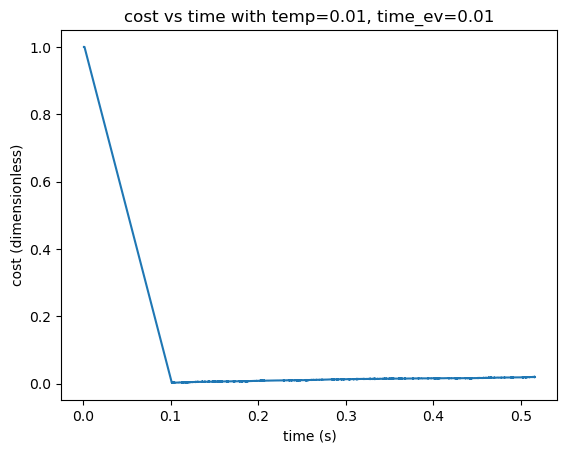

In [14]:

times = list(spindle.trajectory.keys())

costs = []
for time in times:
    costs.append(spindle.trajectory[time]['cost'])

plt.plot(times, costs)
plt.xlabel('time (s)')
plt.ylabel('cost (dimensionless)')
plt.title(f'cost vs time with temp={temp}, time_ev={time_ev}')
# plt.show()

# plot_folder_path = os.path.join(experiment_dir, 'plots')
# os.makedirs(plot_folder_path, exist_ok=True)

cost_plot_path = os.path.join(plot_folder_path, 'cost_time_plot.png')
plt.savefig(cost_plot_path) 